# Segmentacion de datos

Carga inicial del dataset para comparar distintas librerias/metodos de segmentacion.

In [1]:
from pathlib import Path
import importlib.util
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

def is_installed(package_name: str) -> bool:
    return importlib.util.find_spec(package_name) is not None

OPTIONAL_SEGMENTATION_LIBS = {
    "ruptures": is_installed("ruptures"),
    "skchange": is_installed("skchange"),
    "sktime": is_installed("sktime"),
    "stumpy": is_installed("stumpy"),
}

OPTIONAL_SEGMENTATION_LIBS

c:\Users\chdem\anaconda3\envs\Aingurav2\lib\site-packages\sklearn\utils\fixes.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


{'ruptures': True, 'skchange': False, 'sktime': False, 'stumpy': False}

In [2]:
CSV_PATH = Path(r"..\data2\MT002_ENSAYO3_NEW_FEATURES.csv")

# En el directorio aparece esta variante con guion bajo entre ENSAYO y 3.
if not CSV_PATH.exists():
    fallback_path = Path(r"..\data2\MT002_ENSAYO_3_NEW_FEATURES.csv")
    if fallback_path.exists():
        CSV_PATH = fallback_path

if not CSV_PATH.exists():
    raise FileNotFoundError(f"No se ha encontrado el CSV en: {CSV_PATH.resolve()}")

df = pd.read_csv(CSV_PATH, sep=";")

if "timestamp" in df.columns:
    df["timestamp_raw"] = df["timestamp"]
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="us", errors="coerce")
    df = df.set_index("timestamp").sort_index()

numeric_columns = df.select_dtypes(include="number").columns.tolist()
feature_columns = [col for col in numeric_columns if col != "timestamp_raw"]

print(f"Archivo cargado: {CSV_PATH.resolve()}")
print(f"Shape: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
print(f"Columnas numericas para segmentacion: {len(feature_columns)}")

df.head()

Archivo cargado: C:\Users\chdem\0UNIVERSIDAD\Aingura\data2\MT002_ENSAYO_3_NEW_FEATURES.csv
Shape: 103,699 filas x 12 columnas
Columnas numericas para segmentacion: 11


,bal_150,bal_250,bal_350,bal_energy_band_low,bal_energy_band_medium,bal_energy_band_high,6004_FTF,6004_BSF,6004_BPFO,6004_BPFI,likelihood,timestamp_raw
timestamp,,,,,,,,,,,,
2025-08-26 15:46:27.792813,-10.3986,-8.0654,-9.2532,-1045.1293,-3635.2180,-7746.9487,-58.5254,-60.1248,-50.7272,-52.5471,-33.0748,1756223187792813
2025-08-26 15:46:28.292765,-10.3216,-8.0442,-9.2453,-1034.5955,-3600.0193,-7706.6843,-57.5381,-55.9957,-51.4386,-50.5830,-32.1664,1756223188292765
2025-08-26 15:46:28.792715,-10.1709,-8.0505,-9.2517,-1036.2795,-3606.1768,-7736.1006,-57.8739,-58.0901,-50.3769,-52.0278,-32.1664,1756223188792715
2025-08-26 15:46:29.292667,-10.5408,-8.0456,-9.2573,-1058.5239,-3617.2982,-7740.3418,-56.4083,-58.7204,-47.8274,-50.2329,-32.5612,1756223189292667
2025-08-26 15:46:29.792618,-10.2796,-8.0960,-9.2716,-1040.2122,-3591.2787,-7711.5059,-57.1334,-58.9965,-51.6426,-53.4338,-32.5612,1756223189792618


In [3]:
display(df.info())
display(df[feature_columns].describe().T)

missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 103699 entries, 2025-08-26 15:46:27.792813 to 2025-08-27 06:26:23.531781
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   bal_150                 103699 non-null  float64
 1   bal_250                 103699 non-null  float64
 2   bal_350                 103699 non-null  float64
 3   bal_energy_band_low     103699 non-null  float64
 4   bal_energy_band_medium  103699 non-null  float64
 5   bal_energy_band_high    103699 non-null  float64
 6   6004_FTF                103699 non-null  float64
 7   6004_BSF                103699 non-null  float64
 8   6004_BPFO               103699 non-null  float64
 9   6004_BPFI               103699 non-null  float64
 10  likelihood              103699 non-null  float64
 11  timestamp_raw           103699 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 10.3 MB


None

,count,mean,std,min,25%,50%,75%,max
bal_150,103699.0000,-10.1333,0.5258,-10.9308,-10.4739,-10.3252,-9.9227,-7.4457
bal_250,103699.0000,-7.9274,0.2057,-8.7115,-8.0619,-8.0035,-7.8599,-6.4952
bal_350,103699.0000,-9.2954,0.1365,-10.4683,-9.3116,-9.2782,-9.2437,-8.7770
bal_energy_band_low,103699.0000,-955.1774,97.4504,-1085.8951,-1033.3285,-1001.1405,-901.2264,-650.2933
bal_energy_band_medium,103699.0000,-3310.8970,279.6584,-3658.6238,-3577.0691,-3385.5334,-3083.8801,-2642.5180
bal_energy_band_high,103699.0000,-7518.2647,221.0860,-7788.8612,-7708.3063,-7624.7046,-7367.9456,-6890.7184
6004_FTF,103699.0000,-53.7323,5.3419,-66.5911,-57.8322,-55.6855,-49.7782,-34.5034
6004_BSF,103699.0000,-51.0558,7.8390,-67.7724,-57.3971,-54.6632,-44.3193,-26.5762
6004_BPFO,103699.0000,-45.3120,5.1573,-59.2271,-49.5098,-46.3640,-41.5698,-28.4102
6004_BPFI,103699.0000,-44.3941,5.5272,-57.3991,-49.1406,-46.3406,-40.3416,-28.8386


Series([], dtype: int64)

## Prueba 1: ruptures

Deteccion de changepoints con `ruptures` y calculo del tamano de cada ventana detectada.

In [ ]:
try:
    import ruptures as rpt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "No esta instalada la libreria ruptures. Instalala con: pip install ruptures"
    ) from exc

# Parametros principales de la prueba.
RUPTURES_FEATURE_COLUMNS = feature_columns
N_BKPS = 10      # numero de changepoints a buscar
MIN_SIZE = 1000    # minimo de muestras por ventana
JUMP = 5         # evalua candidatos cada JUMP muestras; baja a 1 para maxima precision
MODEL = "l2"     # l2 funciona bien sobre senales escaladas/PCA; prueba tambien "rbf"

valid_mask = df[RUPTURES_FEATURE_COLUMNS].notna().all(axis=1).to_numpy()
valid_rows = np.flatnonzero(valid_mask)
X = df.loc[valid_mask, RUPTURES_FEATURE_COLUMNS]

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Reducimos dimensionalidad para que el detector trabaje sobre la estructura principal.
n_components = min(3, X_scaled.shape[1])
pca = PCA(n_components=n_components, random_state=42)
signal = pca.fit_transform(X_scaled)

print(f"Muestras usadas: {signal.shape[0]:,}")
print(f"Features originales: {X_scaled.shape[1]}")
print(f"Componentes PCA: {signal.shape[1]}")
print(f"Varianza explicada PCA: {pca.explained_variance_ratio_.sum():.2%}")

Muestras usadas: 103,699
Features originales: 11
Componentes PCA: 3
Varianza explicada PCA: 96.39%


In [ ]:
max_bkps = max(1, signal.shape[0] // MIN_SIZE - 1)
n_bkps = min(N_BKPS, max_bkps)

algo = rpt.Binseg(model=MODEL, min_size=MIN_SIZE, jump=JUMP).fit(signal)
bkps = algo.predict(n_bkps=n_bkps)

print(f"Changepoints detectados: {len(bkps) - 1}")
print(f"Indices finales de segmento en la senal usada: {bkps}")

In [6]:
segments = []
start = 0

for segment_id, end in enumerate(bkps, start=1):
    start_pos = valid_rows[start]
    end_pos = valid_rows[end - 1]
    start_time = df.index[start_pos]
    end_time = df.index[end_pos]
    duration = end_time - start_time if isinstance(df.index, pd.DatetimeIndex) else pd.NA

    segments.append(
        {
            "segment_id": segment_id,
            "signal_start_idx": start,
            "signal_end_idx": end - 1,
            "df_start_row": start_pos,
            "df_end_row": end_pos,
            "size_rows": end - start,
            "start_time": start_time,
            "end_time": end_time,
            "duration": duration,
        }
    )
    start = end

windows_df = pd.DataFrame(segments)

display(windows_df)
display(windows_df["size_rows"].describe().to_frame("size_rows"))

,segment_id,signal_start_idx,signal_end_idx,df_start_row,df_end_row,size_rows,start_time,end_time,duration
0,1,0,47614,0,47614,47615,2025-08-26 15:46:27.792813,2025-08-26 22:23:12.473337,0 days 06:36:44.680524
1,2,47615,56339,47615,56339,8725,2025-08-26 22:23:12.973289,2025-08-26 23:35:54.548206,0 days 01:12:41.574917
2,3,56340,66484,56340,66484,10145,2025-08-26 23:35:55.048157,2025-08-27 01:00:26.553881,0 days 01:24:31.505724
3,4,66485,80254,66485,80254,13770,2025-08-27 01:00:27.053833,2025-08-27 02:55:10.882898,0 days 01:54:43.829065
4,5,80255,86814,80255,86814,6560,2025-08-27 02:55:11.382850,2025-08-27 03:49:50.563233,0 days 00:54:39.180383
5,6,86815,89359,86815,89359,2545,2025-08-27 03:49:51.063184,2025-08-27 04:11:02.939217,0 days 00:21:11.876033
6,7,89360,93809,89360,93809,4450,2025-08-27 04:11:03.439168,2025-08-27 04:58:48.008099,0 days 00:47:44.568931
7,8,93810,97184,93810,97184,3375,2025-08-27 04:58:48.508051,2025-08-27 05:26:55.343621,0 days 00:28:06.835570
8,9,97185,97909,97185,97909,725,2025-08-27 05:26:55.843572,2025-08-27 05:32:57.808291,0 days 00:06:01.964719
9,10,97910,100204,97910,100204,2295,2025-08-27 05:32:58.308242,2025-08-27 05:57:16.702104,0 days 00:24:18.393862


,size_rows
count,11.0000
mean,9427.1818
std,13255.0477
min,725.0000
25%,2960.0000
50%,4450.0000
75%,9435.0000
max,47615.0000


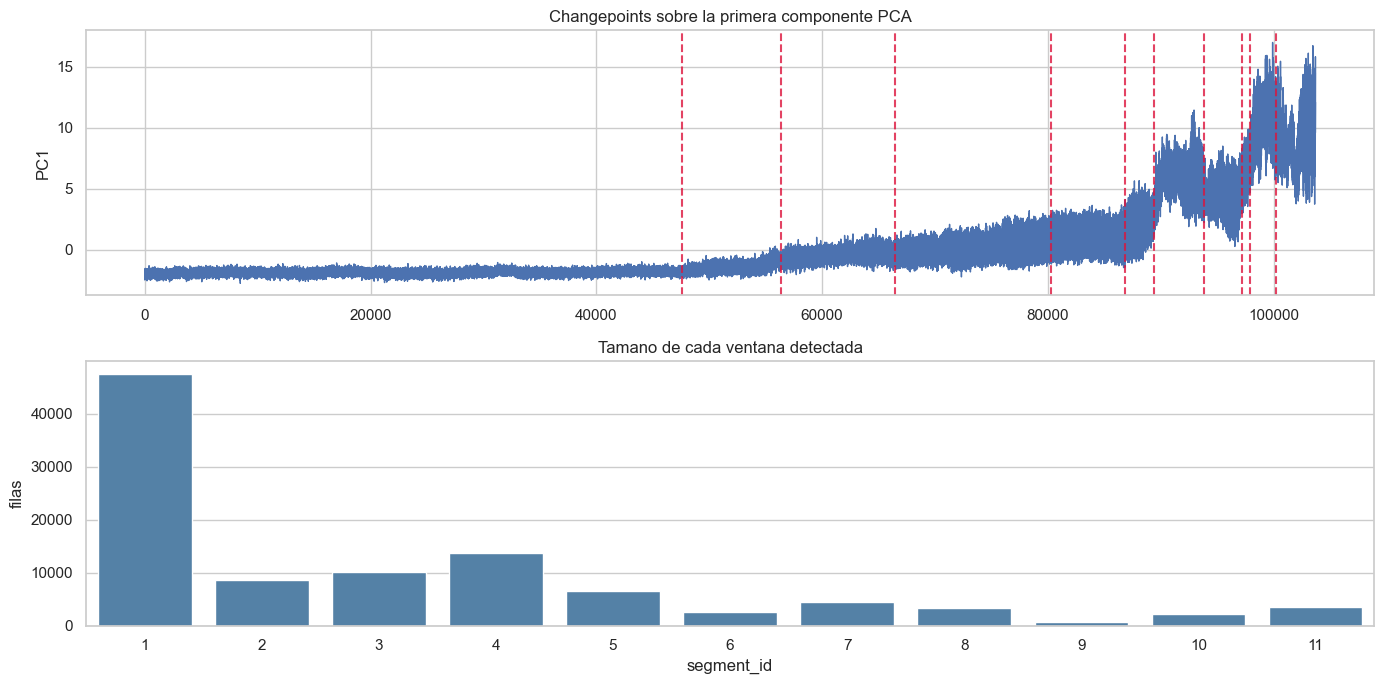

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

axes[0].plot(np.arange(signal.shape[0]), signal[:, 0], linewidth=1)
for bkp in bkps[:-1]:
    axes[0].axvline(bkp, color="crimson", linestyle="--", alpha=0.8)
axes[0].set_title("Changepoints sobre la primera componente PCA")
axes[0].set_ylabel("PC1")

sns.barplot(data=windows_df, x="segment_id", y="size_rows", ax=axes[1], color="steelblue")
axes[1].set_title("Tamano de cada ventana detectada")
axes[1].set_xlabel("segment_id")
axes[1].set_ylabel("filas")

plt.tight_layout()
plt.show()

## Changepoint detection por subconjunto

Separamos por posicion temporal: las primeras 50.000 instancias forman el subconjunto no anomalo y el resto, el subconjunto anomalo. Cada tramo se escala, reduce con PCA y segmenta de forma independiente.

In [ ]:
SPLIT_POSITION = 47_630	
N_BKPS = 5

if len(df) <= SPLIT_POSITION:
    raise ValueError(
        f"El dataset tiene {len(df):,} filas y no contiene observaciones despues de {SPLIT_POSITION:,}."
    )

df_no_anomalo = df.iloc[:SPLIT_POSITION].copy()
df_anomalo = df.iloc[SPLIT_POSITION:].copy()

subsets = {
    "No anomalo": (df_no_anomalo, 0),
    "Anomalo": (df_anomalo, SPLIT_POSITION),
}

for name, (subset, offset) in subsets.items():
    print(
        f"{name}: {len(subset):,} filas | "
        f"{subset.index.min()} -> {subset.index.max()}"
    )

No anomalo: 50,000 filas | 2025-08-26 15:46:27.792813 -> 2025-08-26 22:43:04.857142
Anomalo: 53,699 filas | 2025-08-26 22:43:05.357093 -> 2025-08-27 06:26:23.531781


In [21]:
def detect_changepoints_in_subset(subset, name, global_offset=0):
    """Ajusta ruptures de forma independiente y devuelve ventanas y senal PCA."""
    valid_mask = subset[RUPTURES_FEATURE_COLUMNS].notna().all(axis=1).to_numpy()
    valid_local_positions = np.flatnonzero(valid_mask)
    X_subset = subset.iloc[valid_local_positions][RUPTURES_FEATURE_COLUMNS]

    if len(X_subset) < 2 * MIN_SIZE:
        raise ValueError(
            f"{name} solo tiene {len(X_subset):,} filas validas; "
            f"se necesitan al menos {2 * MIN_SIZE:,}."
        )

    subset_scaler = RobustScaler()
    X_scaled_subset = subset_scaler.fit_transform(X_subset)

    subset_pca = PCA(
        n_components=min(3, X_scaled_subset.shape[1]),
        random_state=42,
    )
    subset_signal = subset_pca.fit_transform(X_scaled_subset)

    max_bkps = max(1, len(subset_signal) // MIN_SIZE - 1)
    subset_n_bkps = min(N_BKPS, max_bkps)
    subset_algo = rpt.Binseg(
        model=MODEL,
        min_size=MIN_SIZE,
        jump=JUMP,
    ).fit(subset_signal)
    subset_bkps = subset_algo.predict(n_bkps=subset_n_bkps)

    segments = []
    start = 0
    for segment_id, end in enumerate(subset_bkps, start=1):
        first_local = int(valid_local_positions[start])
        last_local = int(valid_local_positions[end - 1])
        start_time = subset.index[first_local]
        end_time = subset.index[last_local]
        segments.append({
            "subset": name,
            "segment_id": segment_id,
            "signal_start": start,
            "signal_end": end,
            "global_start_row": global_offset + first_local,
            "global_end_row": global_offset + last_local,
            "size_rows": end - start,
            "start_time": start_time,
            "end_time": end_time,
            "duration": end_time - start_time,
        })
        start = end

    return {
        "signal": subset_signal,
        "bkps": subset_bkps,
        "windows": pd.DataFrame(segments),
        "explained_variance": subset_pca.explained_variance_ratio_,
    }


subset_results = {
    name: detect_changepoints_in_subset(subset, name, offset)
    for name, (subset, offset) in subsets.items()
}

windows_by_subset = pd.concat(
    [result["windows"] for result in subset_results.values()],
    ignore_index=True,
)

display(windows_by_subset)
display(
    windows_by_subset.groupby("subset")["size_rows"]
    .describe()
    .round(2)
)

,subset,segment_id,signal_start,signal_end,global_start_row,global_end_row,size_rows,start_time,end_time,duration
0,No anomalo,1,0,2440,0,2439,2440,2025-08-26 15:46:27.792813,2025-08-26 16:06:47.174081,0 days 00:20:19.381268
1,No anomalo,2,2440,26170,2440,26169,23730,2025-08-26 16:06:47.674032,2025-08-26 19:24:31.018143,0 days 03:17:43.344111
2,No anomalo,3,26170,42660,26170,42659,16490,2025-08-26 19:24:31.518093,2025-08-26 21:41:55.214771,0 days 02:17:23.696678
3,No anomalo,4,42660,47630,42660,47629,4970,2025-08-26 21:41:55.714723,2025-08-26 22:23:19.972607,0 days 00:41:24.257884
4,No anomalo,5,47630,49000,47630,48999,1370,2025-08-26 22:23:20.472558,2025-08-26 22:34:44.905862,0 days 00:11:24.433304
5,No anomalo,6,49000,50000,49000,49999,1000,2025-08-26 22:34:45.405813,2025-08-26 22:43:04.857142,0 days 00:08:19.451329
6,Anomalo,1,0,5485,50000,55484,5485,2025-08-26 22:43:05.357093,2025-08-26 23:28:47.089869,0 days 00:45:41.732776
7,Anomalo,2,5485,8625,55485,58624,3140,2025-08-26 23:28:47.589821,2025-08-26 23:54:56.936858,0 days 00:26:09.347037
8,Anomalo,3,8625,19065,58625,69064,10440,2025-08-26 23:54:57.436810,2025-08-27 01:21:56.428173,0 days 01:26:58.991363
9,Anomalo,4,19065,39535,69065,89534,20470,2025-08-27 01:21:56.928124,2025-08-27 04:18:46.850020,0 days 02:56:49.921896


,count,mean,std,min,25%,50%,75%,max
subset,,,,,,,,
Anomalo,6.0000,8949.8300,6202.7700,3140.0000,5501.0000,7082.0000,9983.7500,20470.0000
No anomalo,6.0000,8333.3300,9506.8200,1000.0000,1637.5000,3705.0000,13610.0000,23730.0000


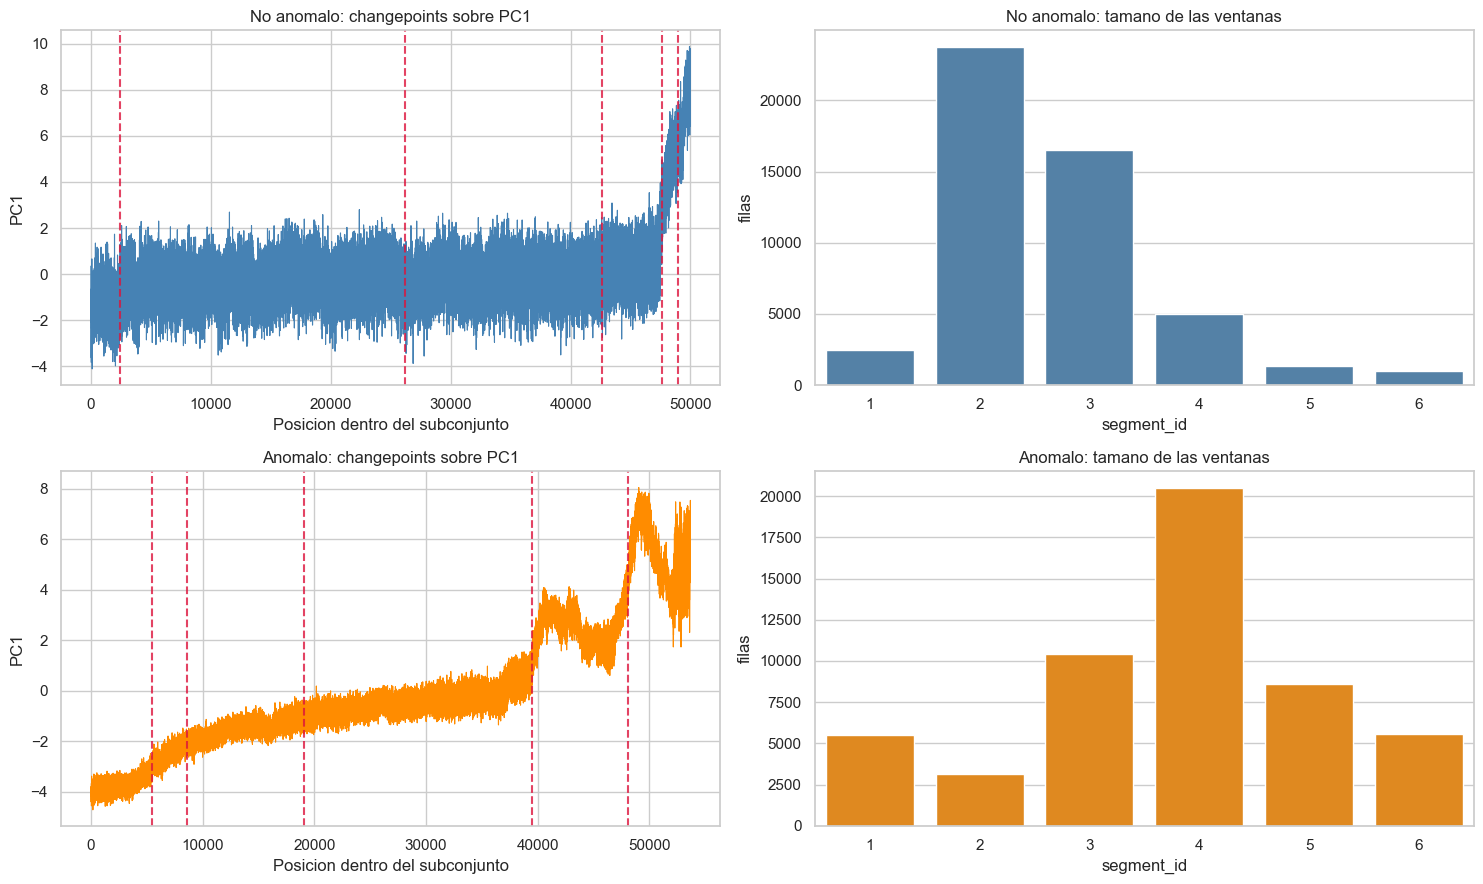

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
colors = {"No anomalo": "steelblue", "Anomalo": "darkorange"}

for row, (name, result) in enumerate(subset_results.items()):
    subset_signal = result["signal"]
    subset_bkps = result["bkps"]
    subset_windows = result["windows"]

    axes[row, 0].plot(subset_signal[:, 0], linewidth=0.8, color=colors[name])
    for bkp in subset_bkps[:-1]:
        axes[row, 0].axvline(bkp, color="crimson", linestyle="--", alpha=0.8)
    axes[row, 0].set_title(f"{name}: changepoints sobre PC1")
    axes[row, 0].set_xlabel("Posicion dentro del subconjunto")
    axes[row, 0].set_ylabel("PC1")

    sns.barplot(
        data=subset_windows,
        x="segment_id",
        y="size_rows",
        ax=axes[row, 1],
        color=colors[name],
    )
    axes[row, 1].set_title(f"{name}: tamano de las ventanas")
    axes[row, 1].set_xlabel("segment_id")
    axes[row, 1].set_ylabel("filas")

plt.tight_layout()
plt.show()

In [11]:
# Ruptures incluye al final la longitud de la senal; [:-1] deja solo changepoints reales.
changepoints_no_anomalo = np.asarray(
    subset_results["No anomalo"]["bkps"][:-1], dtype=int
)
changepoints_anomalo = np.asarray(
    subset_results["Anomalo"]["bkps"][:-1], dtype=int
)

# Posiciones de los changepoints respecto al dataset completo.
changepoints_no_anomalo_global = changepoints_no_anomalo.copy()
changepoints_anomalo_global = changepoints_anomalo + SPLIT_POSITION
changepoints_global = np.concatenate([
    changepoints_no_anomalo_global,
    changepoints_anomalo_global,
])

print("Changepoints no anomalos:", changepoints_no_anomalo)
print("Changepoints anomalos:", changepoints_anomalo)
print("Changepoints globales:", changepoints_global)

Changepoints no anomalos: [ 2460 21325 27365 33015 41890]
Changepoints anomalos: [ 7265 10400 21335 41895 50520]
Changepoints globales: [ 2460 21325 27365 33015 41890 54895 58030 68965 89525 98150]
